# SMART Sampling

---

This notebook **explores soil sampling strategies and sample size determination** for Field 26 (Bulgaria). The workflow includes:

1. **Geometric sampling designs** - Simple approaches based on spatial coordinates:
   - Regular grid sampling with buffer zones
   - Random sampling within grid cells with minimum distance constraints
   - Spatial coverage sampling using k-means to minimize Mean Squared Shortest Distance (MSSD)

2. **Covariate-based stratification** - Using remote sensing variables to guide sampling:
   - Calculate derived indices (NDVI, EVI, SLOPE, ASPECT) from datacube
   - Single-variable stratification (NDVI-only k-means clustering)
   - Multi-variable stratification (NDVI + DEM + Slope in 3D feature space)
   - Cluster visualization and medoid selection for representative sampling points

3. **Sample size calculators** - Determine how many samples are needed:
   - **Raosoft-style calculator**: Standard survey methodology
   - **Soil-specific calculator**: Uses field heterogeneity (Coefficient of Variation) instead of response distribution
   - NDVI variability as proxy for SOC heterogeneity
   - Finite population correction for realistic field sizes
   - Scenario comparisons showing trade-offs between precision and sample size

4. **Power analysis framework** (preliminary) - Statistical foundations for detecting SOC changes over time based on effect size, variability, and sample size

**Key insight**: More heterogeneous fields require more samples to achieve the same precision. NDVI CV serves as a practical proxy for estimating required sample size when actual SOC variability is unknown.

---

#### Open Questions

**K-means clustering optimization** (around cell discussing k-means):
- check clustering algorithm, first high-high-high, low-low-low, ... what then is the optimal amount of clusters to ensure needed diversity?"
- still needs to be linked to BONARES_2_analysis.ipynb: how heterogenous are fields, how many clusters are optimal (field-specific)

**Temporal covariate selection** (mentioned in theoretical sections):
- Should we use NDVI from the exact sampling date, same summer, or previous years?
- If EO variables vary strongly over time, which time horizons are appropriate?
- Is there a cut-off for temporal variability? Should we refrain from using certain variables as stratification basis?


**Validation approaches** (section on validation):
- Need real SOC field data for testing different sampling strategies (BONARES)
- How to validate across multiple fields?
- Which covariates best predict SOC changes within field?

---

#### Pending work:

**Variable extraction for temporal analysis** (mentioned in index calculation section):
   - Dig into temporal analysis

**Power Analysis** (incomplete section):
   - Load SOC tracking data from BONARES
   - Get estimates on SOC variability over time for different sampling locations
   - Currently just placeholder assumptions

**Latin Hypercube Sampling** (marked TBD):
   - Implementation of conditioned LHS (cLHS) for observational studies

**Soil Type Classification** (section noted as "Possible approximation?"):
   - Investigate using satellite data to approximate soil types
   - Currently empty section awaiting implementation

**Sample Size Calculator refinement**:
   - Validate NDVI CV as proxy for SOC heterogeneity using actual data
   - Test different CV scenarios with real field measurements


Basically, fully combine the sampling theory with the data available (BONARES, Pilots, etc.) to gain a "complete" picture on SOC variability, solid stratification variables, needed sample points, heterogeneity and variablility and needed clusters.

---

#### Import libraries and cube

In [13]:
import xarray as xr
import pandas as pd
import numpy as np     
import matplotlib.pyplot as plt  
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as patches
import seaborn as sns
import geopandas as gpd
from shapely.geometry import mapping, Point
from pathlib import Path
import os
import sys  
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scipy.spatial.distance import cdist
import random
import rasterio
from rasterio.crs import CRS
from rasterio.transform import from_bounds

In [14]:
# Define path to the cube
cube_file = Path("/Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/data/smartsoil_experiment/agrovar_sofia26/scaled_fused_S1-S2-DEM_2018_cube.nc")
print("Cube path:", cube_file)

# Open the cube using xarray
ds = xr.open_dataset(cube_file)

Cube path: /Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/data/smartsoil_experiment/agrovar_sofia26/scaled_fused_S1-S2-DEM_2018_cube.nc


### Helper Functions

In [15]:
# HELPERS (potentially extend with "most data available" picker, etc.)

# Clearest Day in summer 2018 (June-August)
def pick_clearest_summer_day(ds, year=2018, cld_var="CLD", max_cloud=2):
    summer_ds = ds.sel(t=slice(f"{year}-06-01", f"{year}-08-31"))
    cld_mean = summer_ds[cld_var].mean(dim=("y", "x"))
    good = cld_mean.where(cld_mean <= max_cloud, drop=True)
    if good.t.size == 0:
        best_t = cld_mean.idxmin()
    else:
        best_t = good.idxmin()
    snap = summer_ds.sel(t=best_t, method="nearest")
    print(f"Picked {np.datetime_as_string(snap['t'].values)} (mean {cld_var}={float(cld_mean.sel(t=snap['t']).values):.3f})")
    return snap

# define clearest day picker - fleeexibleeeee
def pick_clearest_day(ds, start, end, cld_var="CLD", max_cloud=2):
    period_ds = ds.sel(t=slice(start, end))
    cld_mean = period_ds[cld_var].mean(dim=("y", "x"))
    good = cld_mean.where(cld_mean <= max_cloud, drop=True)
    if good.t.size == 0:
        best_t = cld_mean.idxmin()
    else:
        best_t = good.idxmin()
    snap = period_ds.sel(t=best_t, method="nearest")
    print(f"Picked {np.datetime_as_string(snap['t'].values)} (mean {cld_var}={float(cld_mean.sel(t=snap['t']).values):.3f})")
    return snap


## KICK OFF: **Sampling Strategies**

Probability sampling: Probability sampling is random sampling fulfilling two requirements. 

 1. All units in the population have a positive prob. of being selected.
 2. Selection probability of each possible sample is known.

The choice between probability or non-probability sampling is connected with the choice between a design-based or model-based approach for statistical inference. A model-based approach for sampling and statistical inference does not necessarily imply model-based sampling. The adjective model-based refers to the model based inference, not to the selection of the locations.


Source: _Brus, 2018_

### Geometric sampling designs

#### Simple grid sampling

This should be the equivalent to the function spsample of the R package sp. 
Sampling on a regular grid, reprojecting it to the UTM zone (so we can use metrics), simply define a buffer distance to the border of the shapefile and then define a grid spacing denoted by the edge points (red). 

Further we can also just randomly sample points across the grids within the boundary. E.g., definining a certain amount of points to be randomly sampled, defining the spacing between the points or other options. 


Source: Brus, 2018

<Axes: >

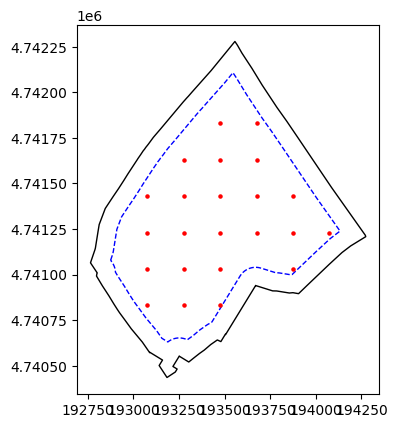

In [16]:
# Read AOI and project
aoi = gpd.read_file("/Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/input/smartsoil_experiment/agrovar_sofia26/field26.shp").to_crs(epsg=32635)

# Buffer inward (exclude edge)
buffer_distance = 100  # meters / free to adapt buffer zone
aoi_inner = aoi.copy()
aoi_inner["geometry"] = aoi_inner.buffer(-buffer_distance)

# Use bounds of buffered AOI for grid
minx, miny, maxx, maxy = aoi_inner.total_bounds

spacing = 200  # meters / free to adjust grid spacing
x_coords = np.arange(minx, maxx, spacing)
y_coords = np.arange(miny, maxy, spacing)
points = [Point(x, y) for x in x_coords for y in y_coords]

# Keep only points inside buffered AOI
grid = gpd.GeoDataFrame(geometry=points, crs=aoi.crs)
grid = grid[grid.within(aoi_inner.geometry.union_all())]

# Plot
ax = aoi.plot(edgecolor="black", facecolor="none")
aoi_inner.plot(ax=ax, edgecolor="blue", facecolor="none", linestyle="--")
grid.plot(ax=ax, color="red", markersize=5)

# # Optional: Plot grid boundaries (lines)
# for x in x_coords:
#     ax.plot([x, x], [miny, maxy], color="gray", linewidth=0.5, alpha=0.5)
# for y in y_coords:
#     ax.plot([minx, maxx], [y, y], color="gray", linewidth=0.5, alpha=0.5)

<Axes: >

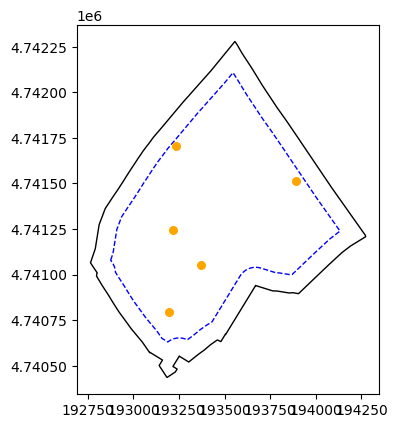

In [17]:
n_total_points = 5 # total random points to sample / free to adjust
min_dist = 200  # minimum distance in meters between points / free to adjust

# Create a list of grid cells
cells = []
for x in x_coords[:-1]:
    for y in y_coords[:-1]:
        cell_minx, cell_maxx = x, x + spacing
        cell_miny, cell_maxy = y, y + spacing
        cells.append((cell_minx, cell_maxx, cell_miny, cell_maxy))

random_points = []
attempts = 0
while len(random_points) < n_total_points and attempts < n_total_points * 100:
    cell = random.choice(cells)
    cell_minx, cell_maxx, cell_miny, cell_maxy = cell
    rx = random.uniform(cell_minx, cell_maxx)
    ry = random.uniform(cell_miny, cell_maxy)
    pt = Point(rx, ry)
    if pt.within(aoi_inner.geometry.union_all()):
        # Check minimum distance to existing points
        if all(pt.distance(existing) >= min_dist for existing in random_points):
            random_points.append(pt)
    attempts += 1  # avoid infinite loop

random_grid = gpd.GeoDataFrame(geometry=random_points, crs=aoi.crs)

# Plot AOI, buffer, grid boundaries, and random points
ax = aoi.plot(edgecolor="black", facecolor="none")
aoi_inner.plot(ax=ax, edgecolor="blue", facecolor="none", linestyle="--")
random_grid.plot(ax=ax, color="orange", markersize=30)

### Covariates

What are important variables that we could use as potential basis for stratification or as covariates in other statistical sampling methods?


- __Elevation__: We can pull elevation from our Copernicus Digital Eleveation Model (DEM)
- __Slope__: We can calculate the slope (the steepness) of our AOI based on the elevation information from Copernicus DEM. It is derived from the spatial gradients of elevation in the x (east–west) and y (north–south) directions.
```
dy, dx = np.gradient(dem)
slope = np.sqrt(dx**2 + dy**2) 
```
- __NDVI__ (Normalized Difference Vegetation Index): Assesses the health and density of vegetation by comparing the light reflected from vegetation in the near-infrared (NIR) and red (visible light) wavelengths using remote sensing data. 
```
NDVI = (NIR - RED) / (NIR + RED) = (B08 - B04) / (B08 + B04)
```
- __NDMI__ (Normalized Difference Moisture Index): Remote sensing index that quantifies vegetation water content using near-infrared (NIR) and short-wave infrared (SWIR) satellite bands.
```
NDMI = (NIR - SWIR) / (NIR + SWIR) = (B08 - B11) / (B08 + B11)
```


Important but not yet in Data Cube:
- __Soil Type__: Could get it from ESDAC or LUCAS database and merge it into cube? 

And then ...
MANY MANY MORE!

In [18]:
# Create new variables in the xarray dataset

# NDVI = (NIR - Red) / (NIR + Red)
print("Creating NDVI")
ndvi_all = (ds["B08"] - ds["B04"]) / (ds["B08"] + ds["B04"])
ds = ds.assign(NDVI=ndvi_all)  # Remove the dimension specification

# SLOPE from DEM (static)
print("Creating SLOPE")
dem = ds["DEM"].isel(t=0).values  # DEM is static, take first time step
dy, dx = np.gradient(dem)
slope = np.sqrt(dx**2 + dy**2)
# Broadcast slope to all time steps to match cube structure
slope_broadcasted = np.broadcast_to(slope, ds["DEM"].shape)
ds = ds.assign(SLOPE=(("t","y","x"), slope_broadcasted))

# ASPECT from DEM (static)
print("Creating ASPECT")
aspect = np.arctan2(-dx, dy)
aspect_broadcasted = np.broadcast_to(aspect, ds["DEM"].shape)
ds = ds.assign(ASPECT=(("t","y","x"), aspect_broadcasted))

# EVI (Enhanced Vegetation Index) - EVI = 2.5 * (NIR - Red) / (NIR + 6*Red - 7.5*Blue + 1)
print("Creating EVI")
evi_all = 2.5 * (ds["B08"] - ds["B04"]) / (ds["B08"] + 6*ds["B04"] - 7.5*ds["B02"] + 1)
ds = ds.assign(EVI=evi_all)  # Remove the dimension specification

print("Variables created successfully.")
print("Available variables:", list(ds.data_vars))
print("Dataset shape:", ds.sizes)

Creating NDVI
Creating SLOPE
Creating ASPECT
Creating EVI
Variables created successfully.
Available variables: ['crs', 'B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B11', 'B12', 'WVP', 'AOT', 'SCL', 'sunAzimuthAngles', 'sunZenithAngles', 'viewAzimuthMean', 'viewZenithMean', 'CLD', 'SNW', 'VH', 'VV', 'DEM', 'NDVI', 'SLOPE', 'ASPECT', 'EVI']
Dataset shape: Frozen({'t': 730, 'y': 187, 'x': 150})


#### Other sampling techniques based on spatial coordinates

    Spatial Coverage Sampling 
With regular grid sampling of irregularly shaped areas, the spreading throughout the AOI can be suboptimal. From the idea of shifting grid points into the undersampled area came spatial coverage sampling, in which a geometric criterion defined in terms of distances between the nodes of a . Brus et al. (2007) proposed the Mean Squared Shortest Distance (MSSD) by k-means. Basically trying to spread the samples more throughout the field and avoid clustering. 

    Spatial Infill Sampling 
Is applicapple if there are already samples done with known spatial coordinates (legacy point data) and their validity is given. If we don't want to sample in the neighboring areas (too close) but rather want to fill-in the undersampled area, we can rely on the spatial infill method.


Source: Brus, 2018

In [19]:
# Spatial Coverage Sampling

# Define function

def field_spatial_coverage_sampling(ds, shapefile_path, n_samples=5, n_tries=10, buffer_m=-50):
    """Simple spatial coverage sampling within field boundary."""
    
    # Load field boundary and reproject to match cube CRS (UTM 34N)
    field = gpd.read_file(shapefile_path).to_crs(epsg=32634)  # Changed to 32634 (UTM 34N)
    if buffer_m != 0:
        field_geom = field.geometry.buffer(buffer_m).union_all()
    else:
        field_geom = field.geometry.union_all()
    
    print(f"Field bounds (reprojected): {field.total_bounds}")
    print(f"Cube bounds: x={ds.x.min().item():.1f} to {ds.x.max().item():.1f}, y={ds.y.min().item():.1f} to {ds.y.max().item():.1f}")
    
    # Get pixel coordinates
    x_coords = ds.x.values
    y_coords = ds.y.values
    
    # Find pixels inside field
    field_pixels = []
    for i, y in enumerate(y_coords):
        for j, x in enumerate(x_coords):
            if Point(x, y).within(field_geom):
                field_pixels.append([x, y])
    
    coords = np.array(field_pixels)
    print(f"Found {len(coords)} pixels within field")
    
    if len(coords) < n_samples:
        print(f"Warning: Only {len(coords)} pixels found, reducing n_samples to {len(coords)}")
        n_samples = len(coords)
    
    # Run k-means for best spatial coverage
    best_mssd = np.inf
    best_labels = None
    
    for _ in range(n_tries):
        kmeans = KMeans(n_clusters=n_samples, random_state=np.random.randint(1000))
        labels = kmeans.fit_predict(coords)
        
        # Calculate MSSD
        mssd = 0
        for cluster_id in range(n_samples):
            cluster_coords = coords[labels == cluster_id]
            if len(cluster_coords) > 1:
                distances = cdist(cluster_coords, cluster_coords)
                np.fill_diagonal(distances, np.inf)
                mssd += np.sum(distances.min(axis=1) ** 2)
        mssd /= len(coords)
        
        if mssd < best_mssd:
            best_mssd = mssd
            best_labels = labels
    
    # Select representative points
    sample_points = []
    for cluster_id in range(n_samples):
        cluster_coords = coords[best_labels == cluster_id]
        if len(cluster_coords) > 0:
            centroid = cluster_coords.mean(axis=0)
            distances = cdist([centroid], cluster_coords)[0]
            sample_points.append(cluster_coords[distances.argmin()])
    
    sample_points = np.array(sample_points)
    print(f"Selected {len(sample_points)} sample points, MSSD = {best_mssd:.2f}")
    
    return sample_points, coords, best_labels, field_geom


Field bounds (reprojected): [ 683730.71469665 4736072.41851902  685224.87679495 4737935.28086137]
Cube bounds: x=683735.0 to 685225.0, y=4736075.0 to 4737935.0
Found 11825 pixels within field
Selected 10 sample points, MSSD = 100.00


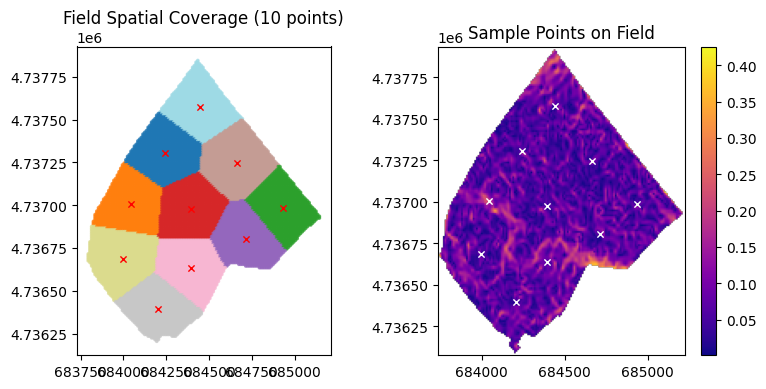

In [20]:
# Execute
samples, all_pixels, labels, field_geom = field_spatial_coverage_sampling(
    ds, 
    "/Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/input/smartsoil_experiment/agrovar_sofia26/field26.shp",
    n_samples=10,
    buffer_m=-50  # 50m inward buffer
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Plot 1: Clusters
axes[0].scatter(all_pixels[:, 0], all_pixels[:, 1], c=labels, s=3, alpha=0.7, cmap="tab20")
axes[0].scatter(samples[:, 0], samples[:, 1], c="red", marker="x", s=20, linewidth=1)
axes[0].set_title(f"Field Spatial Coverage ({len(samples)} points)")
axes[0].set_aspect("equal")

# Plot 2: On Slope 
snap = ds.isel(t=0)
im = axes[1].imshow(snap["SLOPE"].values, extent=[snap.x.min(), snap.x.max(), snap.y.min(), snap.y.max()], cmap="plasma")
axes[1].scatter(samples[:, 0], samples[:, 1], c="white", marker="x", s=20, linewidth=1)
axes[1].set_title("Sample Points on Field")
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

## Stratified K-means sampling

In regular grid and spatial coverage sampling, the selection of the sampling locations is entirely __based on spatial coordinates of locations__. Covariates are not accounted for. This is potentially suboptimal, when the soil property of interest is related to covariates of which maps are availabe (in our case remote sensing).

In K-means sampling, the covariates are used to cluster the grid cells according to the k-means clustering algorithm. Similar to spatial coverage sampling, the MSSD is minimized, but now distance is not in the euclidean space, but in p-dimensional space, spanned by p covariates. If we only have one covariate, e.g., NDVI, this results in just a clustering of higher vs. lower values of only NDVI. K-means does __not create equal sized clusters__. It clusters pixels based on the similarity in feature space and minimizes the within cluster-variance, not the cluster size.We are focusing on __hard k-means__. Hard k-means (as opposed to fuzzy/soft k-means) means that __each unit can only belong to exactly one cluster__. 

__Potential problems__: With hard/fuzzy k-means sampling, the selected sampling points will tend to be concentrated in those parts of the multivariate distribution where the densitiy of points is the largest. The "extremes" of the distribution, however, may be undersampled. (--> see smapling graph below using NDVI, slope and DEM - the area that was of particular interest, was not sampled at all - could be a potential explanation)

**Q**: _check clustering algorithm, first high-high-high, low-low-low, ... what then is the optimal amount uf clusters to ensure needed diversty?_

### Stratified sampling using only one covariate (NDVI)

We will start, however, by only using one covariate each.

And we start by just focusing on one snapshot in time (Summer) in a given year.


Growing season: April-September 2018 (183 time steps)
Using 13951 valid pixels for clustering
Clustering variables: ['NDVI']
Selected 10 representative sample points

NDVI ranges: 0.410 - 0.685


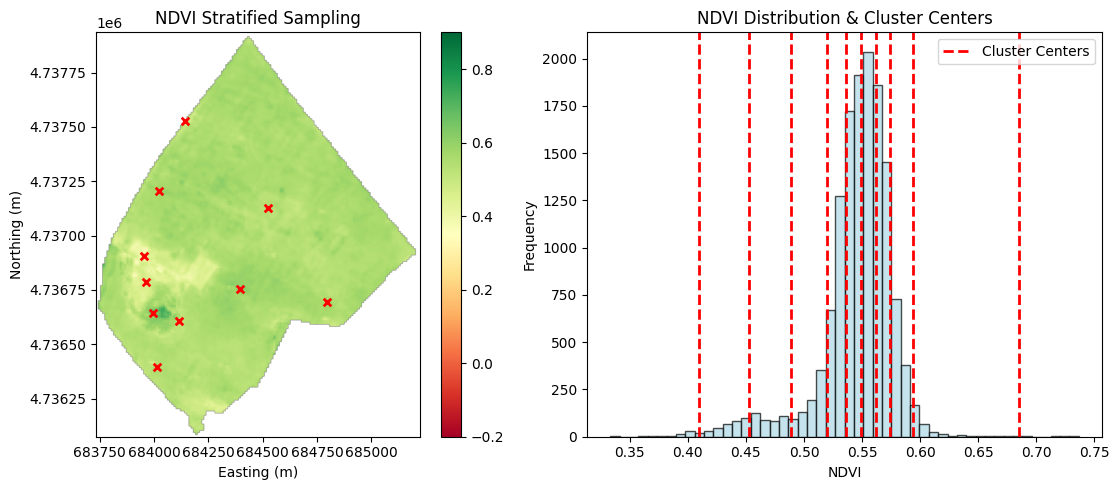


Sample points NDVI values:
Sample 1: NDVI = 0.536
Sample 2: NDVI = 0.562
Sample 3: NDVI = 0.410
Sample 4: NDVI = 0.489
Sample 5: NDVI = 0.520
Sample 6: NDVI = 0.593
Sample 7: NDVI = 0.549
Sample 8: NDVI = 0.685
Sample 9: NDVI = 0.574
Sample 10: NDVI = 0.452


In [21]:
# Stratified sampling using k-means clustering - NDVI only

# Snapshot growing season (April-September 2018)
growing_season = ds.sel(t=slice("2018-04-01", "2018-09-30"))
snap = growing_season.mean(dim="t")   # Average all variables over growing season
print(f"Growing season: April-September 2018 ({growing_season.sizes['t']} time steps)")

# Flatten spatial dimensions and convert to DataFrame - NDVI only
variables_for_clustering = ["NDVI"]  # Only NDVI
df = snap[variables_for_clustering].to_dataframe().reset_index()
df = df.dropna() # Drop rows with any NaNs

print(f"Using {len(df)} valid pixels for clustering")
print(f"Clustering variables: {variables_for_clustering}")

# Run k-means clustering (stratification) - 1D clustering on NDVI

n = 10 # number of strata / results in final amount of sample points / free to adjust

covars = df[variables_for_clustering].values
kmeans = KMeans(n_clusters=n, random_state=42)
df["cluster"] = kmeans.fit_predict(covars)

# Find representative points (medoids)
centroids = kmeans.cluster_centers_
sample_indices = []

for cluster_id in range(n):
    cluster_data = df[df["cluster"] == cluster_id]
    if len(cluster_data) > 0:
        distances = np.abs(cluster_data["NDVI"].values - centroids[cluster_id][0])
        medoid_idx = cluster_data.index[distances.argmin()]
        sample_indices.append(medoid_idx)

sample_points = df.loc[sample_indices, ["x","y"] + variables_for_clustering + ["cluster"]]

print(f"Selected {len(sample_points)} representative sample points")
print(f"\nNDVI ranges: {sample_points['NDVI'].min():.3f} - {sample_points['NDVI'].max():.3f}")

# Plot NDVI map with sample points
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: NDVI map with samples
x_coords = snap.x.values
y_coords = snap.y.values
im = axes[0].imshow(snap["NDVI"].values, cmap="RdYlGn", vmin=-0.2, vmax=0.9, 
                    extent=[x_coords.min(), x_coords.max(), y_coords.min(), y_coords.max()])
axes[0].scatter(sample_points["x"], sample_points["y"], c="red", marker="x", s=30, linewidth=2)
axes[0].set_title("NDVI Stratified Sampling")
axes[0].set_xlabel("Easting (m)")
axes[0].set_ylabel("Northing (m)")
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# Plot 2: NDVI histogram with cluster centers
axes[1].hist(df["NDVI"], bins=50, alpha=0.7, color="lightblue", edgecolor="black")
for i, center in enumerate(centroids):
    axes[1].axvline(center[0], color="red", linestyle="--", linewidth=2, 
                   label=f"Cluster {i}" if i == 0 else "")
axes[1].set_xlabel("NDVI")
axes[1].set_ylabel("Frequency")
axes[1].set_title("NDVI Distribution & Cluster Centers")
axes[1].legend(["Cluster Centers"])

plt.tight_layout()
plt.show()

print(f"\nSample points NDVI values:")
for i, (_, point) in enumerate(sample_points.iterrows()):
    print(f"Sample {i+1}: NDVI = {point['NDVI']:.3f}")

Growing season: April-September 2018 (183 time steps)
Applied 50m inward buffer to avoid field edges
Original pixels: 13951, After buffer: 11825
Clustering variables: ['NDVI']
Selected 10 representative sample points (within buffer)

NDVI ranges: 0.412 - 0.687


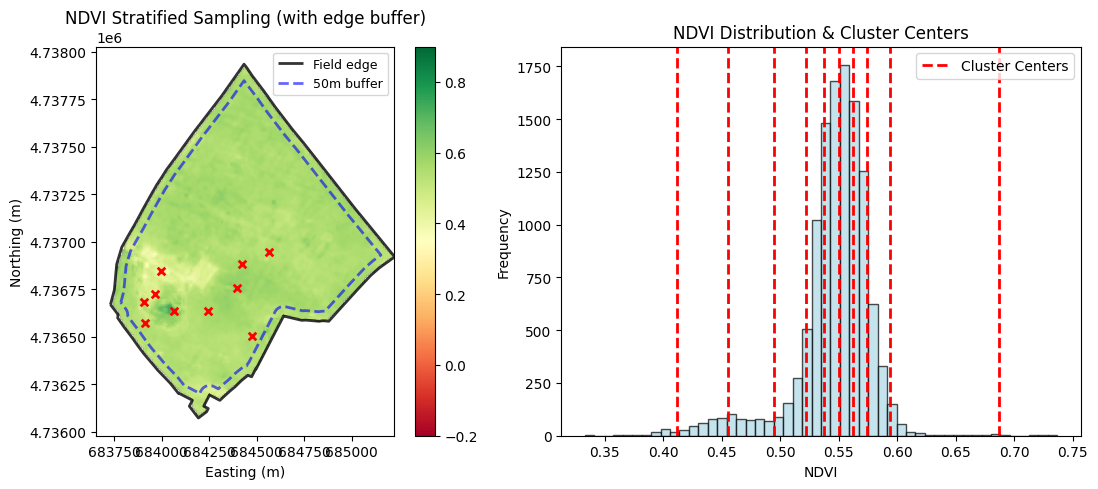


Sample points NDVI values:
Sample 1: NDVI = 0.574
Sample 2: NDVI = 0.537
Sample 3: NDVI = 0.455
Sample 4: NDVI = 0.562
Sample 5: NDVI = 0.495
Sample 6: NDVI = 0.412
Sample 7: NDVI = 0.593
Sample 8: NDVI = 0.687
Sample 9: NDVI = 0.522
Sample 10: NDVI = 0.550


In [22]:
# Stratified sampling using k-means clustering - NDVI only (WITH 10m BUFFER)

# Snapshot growing season (April-September 2018)
growing_season = ds.sel(t=slice("2018-04-01", "2018-09-30"))
snap = growing_season.mean(dim="t")   # Average all variables over growing season
print(f"Growing season: April-September 2018 ({growing_season.sizes['t']} time steps)")

# Load field boundary and create buffer zone (10m inward to avoid edge effects)
buffer_distance = -50  # negative = inward buffer in meters
field_boundary = gpd.read_file("/Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/input/smartsoil_experiment/agrovar_sofia26/field26.shp")
field_boundary = field_boundary.to_crs(epsg=32634)  # Match datacube CRS
field_buffered = field_boundary.copy()
field_buffered['geometry'] = field_boundary.geometry.buffer(buffer_distance)

print(f"Applied {abs(buffer_distance)}m inward buffer to avoid field edges")

# Flatten spatial dimensions and convert to DataFrame - NDVI only
variables_for_clustering = ["NDVI"]  # Only NDVI
df = snap[variables_for_clustering].to_dataframe().reset_index()
df = df.dropna() # Drop rows with any NaNs

# Filter pixels to only those within buffered boundary
from shapely.geometry import Point
df['point'] = df.apply(lambda row: Point(row['x'], row['y']), axis=1)
df['within_buffer'] = df['point'].apply(lambda p: field_buffered.geometry.contains(p).any())
df_buffered = df[df['within_buffer']].drop(columns=['point', 'within_buffer'])

print(f"Original pixels: {len(df)}, After buffer: {len(df_buffered)}")
print(f"Clustering variables: {variables_for_clustering}")

# Run k-means clustering (stratification) - 1D clustering on NDVI

n = 10 # number of strata / results in final amount of sample points / free to adjust

covars = df_buffered[variables_for_clustering].values
kmeans = KMeans(n_clusters=n, random_state=42)
df_buffered["cluster"] = kmeans.fit_predict(covars)

# Find representative points (medoids)
centroids = kmeans.cluster_centers_
sample_indices = []

for cluster_id in range(n):
    cluster_data = df_buffered[df_buffered["cluster"] == cluster_id]
    if len(cluster_data) > 0:
        distances = np.abs(cluster_data["NDVI"].values - centroids[cluster_id][0])
        medoid_idx = cluster_data.index[distances.argmin()]
        sample_indices.append(medoid_idx)

sample_points_buffered = df_buffered.loc[sample_indices, ["x","y"] + variables_for_clustering + ["cluster"]]

print(f"Selected {len(sample_points_buffered)} representative sample points (within buffer)")
print(f"\nNDVI ranges: {sample_points_buffered['NDVI'].min():.3f} - {sample_points_buffered['NDVI'].max():.3f}")

# Plot NDVI map with sample points
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: NDVI map with samples
x_coords = snap.x.values
y_coords = snap.y.values
im = axes[0].imshow(snap["NDVI"].values, cmap="RdYlGn", vmin=-0.2, vmax=0.9, 
                    extent=[x_coords.min(), x_coords.max(), y_coords.min(), y_coords.max()])
axes[0].scatter(sample_points_buffered["x"], sample_points_buffered["y"], c="red", marker="x", s=30, linewidth=2)

# Add field boundaries (original and buffered)
field_boundary.boundary.plot(ax=axes[0], color='black', linewidth=2, alpha=0.8, label='Field edge')
field_buffered.boundary.plot(ax=axes[0], color='blue', linewidth=2, linestyle='--', alpha=0.6, label=f'{abs(buffer_distance)}m buffer')

axes[0].set_title("NDVI Stratified Sampling (with edge buffer)")
axes[0].set_xlabel("Easting (m)")
axes[0].set_ylabel("Northing (m)")
axes[0].legend(loc='upper right', fontsize=9)
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# Plot 2: NDVI histogram with cluster centers
axes[1].hist(df_buffered["NDVI"], bins=50, alpha=0.7, color="lightblue", edgecolor="black")
for i, center in enumerate(centroids):
    axes[1].axvline(center[0], color="red", linestyle="--", linewidth=2, 
                   label=f"Cluster {i}" if i == 0 else "")
axes[1].set_xlabel("NDVI")
axes[1].set_ylabel("Frequency")
axes[1].set_title("NDVI Distribution & Cluster Centers")
axes[1].legend(["Cluster Centers"])

plt.tight_layout()
plt.show()

print(f"\nSample points NDVI values:")
for i, (_, point) in enumerate(sample_points_buffered.iterrows()):
    print(f"Sample {i+1}: NDVI = {point['NDVI']:.3f}")

In [23]:
df_buffered["cluster"].value_counts().sort_index()

cluster
0    1738
1    2295
2     433
3    2480
4     381
5     181
6     537
7      36
8    1147
9    2597
Name: count, dtype: int64

### Stratified sampling using a multidimensional sampling space

If we want to use multiple variables for clustering, let's say **NDVI, slope and elevation**, we create a 3-dimentional space, where similar pixels are being clustered, meaning having the shortest distances of the 3 respective variables (think of it as a multi-dimensional scatter plot with the covariates along the axis). 

Groups pixels together that are close in the following distance:

**distance = √[(slope₁-slope₂)² + (DEM₁-DEM₂)² + (NDVI₁-NDVI₂)²]**

In [24]:
# range of NDVI, DEM and slope
print("NDVI min, max:", ds["NDVI"].min().item(), ds["NDVI"].max().item())
print("DEM min, max:", ds["DEM"].min().item(), ds["DEM"].max().item())
print("Slope min, max:", ds["SLOPE"].min().item(), ds["SLOPE"].max().item())

NDVI min, max: -0.24612733721733093 0.9503775835037231
DEM min, max: 533.6534423828125 538.0430908203125
Slope min, max: 0.0010733340168371797 0.4256923198699951


In [25]:
# Standardize before clustering
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[variables_for_clustering])
df["cluster"] = kmeans.fit_predict(scaled_features)

In [26]:
# Stratified sampling using k-means clustering using 3 (NDVI, DEM, SLOPE) covariates

# Snapshot growing season (April-September 2018)
growing_season = ds.sel(t=slice("2018-04-01", "2018-09-30"))
snap = growing_season.mean(dim="t")   # Average all variables over growing season
print(f"Growing season: April-September 2018 ({growing_season.sizes['t']} time steps)")

# Flatten spatial dimensions and convert to DataFrame
variables_for_clustering = ["DEM", "SLOPE", "NDVI"]  # Choose which variables to use
df = snap[variables_for_clustering].to_dataframe().reset_index()
df = df.dropna() # Drop rows with any NaNs
# Result should have columns: y, x, DEM, SLOPE, NDVI

print(f"Using {len(df)} valid pixels for clustering")
print(f"Clustering variables: {variables_for_clustering}")

# Run k-means clustering (stratification) with standardization
#  This clusters our pixels into n strata based on our chosen variables. Similar pixels, in the three dimensional space, will be grouped together in the same cluster. 
from sklearn.preprocessing import StandardScaler

n = 15  # number of strata
# Standardize before clustering to give equal weight to all variables (otherwise DEM dominates)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[variables_for_clustering])

kmeans = KMeans(n_clusters=n, random_state=42)
df["cluster"] = kmeans.fit_predict(scaled_features)

# Now we have a df including the vars and the cluster assignment

# Seeing as the cluster is a cloud of pixels, we now need to pick a representative pixel from each cluster
# Find representative points (medoids)
# So we create an "average" point of each cluster (the centroid) and then find the pixel closest to that centroid (the medoid) by 
# calculating the Euclidean distance from each pixel in the cluster to the centroid and picking the one with the smallest distance.

# Find representative points (medoids) using ORIGINAL (non-standardized) values
centroids = kmeans.cluster_centers_  # These are in standardized space
sample_indices = []

for cluster_id in range(n):
    cluster_data = df[df["cluster"] == cluster_id]
    if len(cluster_data) > 0:
        # Scale cluster data to match centroids
        cluster_scaled = scaler.transform(cluster_data[variables_for_clustering])
        distances = np.linalg.norm(cluster_scaled - centroids[cluster_id], axis=1)
        medoid_idx = cluster_data.index[distances.argmin()]
        sample_indices.append(medoid_idx)

sample_points = df.loc[sample_indices, ["x","y"] + variables_for_clustering + ["cluster"]]

print(f"Selected {len(sample_points)} representative sample points")
print("\nSample point ranges:")
for var in variables_for_clustering:
    print(f"{var}: {sample_points[var].min():.3f} - {sample_points[var].max():.3f}")

Growing season: April-September 2018 (183 time steps)
Using 13821 valid pixels for clustering
Clustering variables: ['DEM', 'SLOPE', 'NDVI']
Selected 15 representative sample points

Sample point ranges:
DEM: 534.580 - 536.635
SLOPE: 0.030 - 0.231
NDVI: 0.431 - 0.654


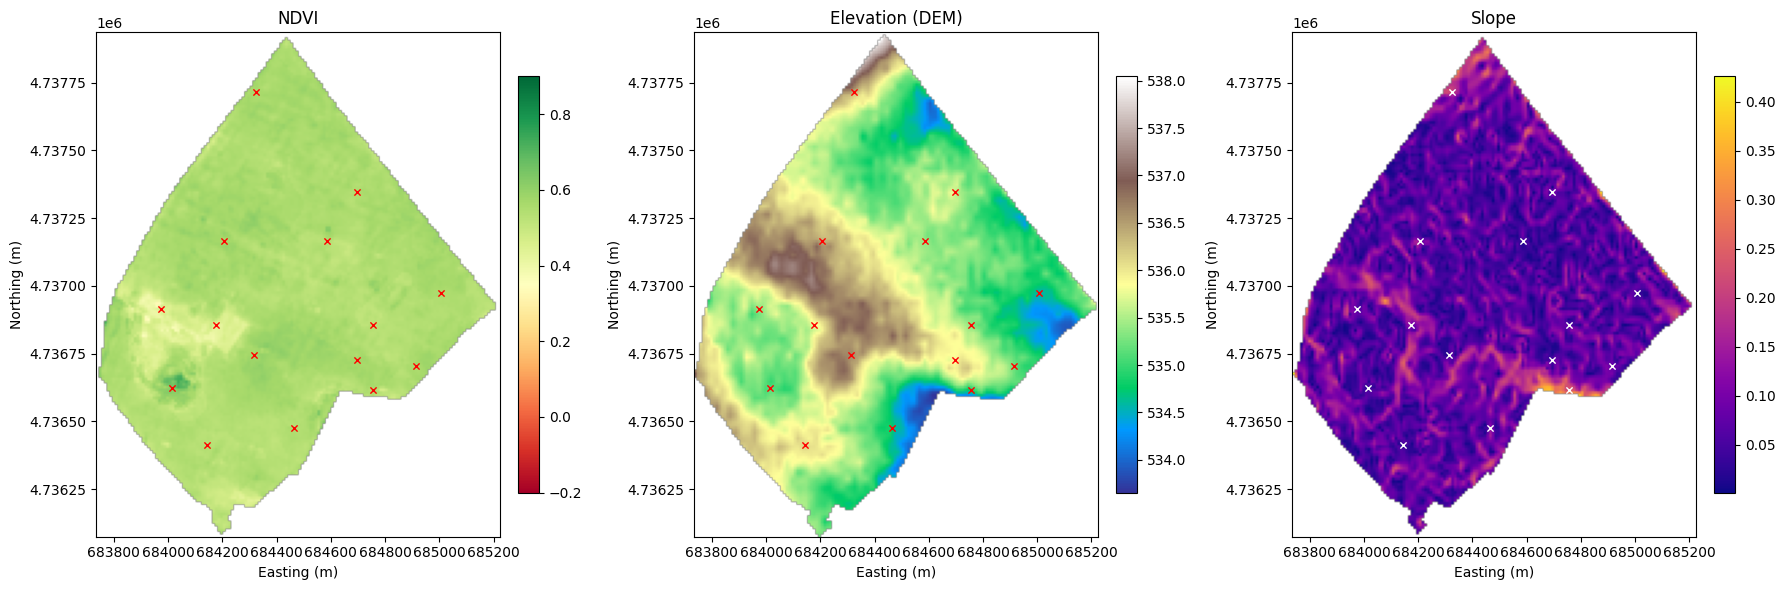

In [27]:
# Visualize field maps with sample points
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Convert sample point coordinates to image indices for plotting
x_coords = snap.x.values
y_coords = snap.y.values

# Find pixel indices for sample points
sample_i_indices = []
sample_j_indices = []
for _, point in sample_points.iterrows():
    # Find closest x and y indices
    i_idx = np.argmin(np.abs(y_coords - point['y']))
    j_idx = np.argmin(np.abs(x_coords - point['x']))
    sample_i_indices.append(i_idx)
    sample_j_indices.append(j_idx)

# Plot 1: NDVI (vegetation)
im1 = axes[0].imshow(snap["NDVI"].values, cmap="RdYlGn", vmin=-0.2, vmax=0.9, extent=[x_coords.min(), x_coords.max(), y_coords.min(), y_coords.max()])
axes[0].scatter(sample_points["x"], sample_points["y"], c="red", marker="x", s=20, linewidth=1)
axes[0].set_title("NDVI")
axes[0].set_xlabel("Easting (m)")
axes[0].set_ylabel("Northing (m)")
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# Plot 2: DEM (elevation)
im2 = axes[1].imshow(snap["DEM"].values, cmap="terrain", extent=[x_coords.min(), x_coords.max(), y_coords.min(), y_coords.max()])
axes[1].scatter(sample_points["x"], sample_points["y"], c="red", marker="x", s=20, linewidth=1)
axes[1].set_title("Elevation (DEM)")
axes[1].set_xlabel("Easting (m)")
axes[1].set_ylabel("Northing (m)")
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

# Plot 3: Slope
im3 = axes[2].imshow(snap["SLOPE"].values, cmap="plasma", extent=[x_coords.min(), x_coords.max(), y_coords.min(), y_coords.max()])
axes[2].scatter(sample_points["x"], sample_points["y"], c="white", marker="x", s=20, linewidth=1)
axes[2].set_title("Slope")
axes[2].set_xlabel("Easting (m)")
axes[2].set_ylabel("Northing (m)")
plt.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [28]:
# Plot without background maps, only pixels and samples
# plt.figure(figsize=(3,3))
# plt.scatter(df["x"], df["y"], s=0.3, alpha=0.2, label="All pixels")
# plt.scatter(sample_points["x"], sample_points["y"], c="red", marker="x", s=50, label="Samples")
# plt.legend()
# plt.title("Stratified sampling k-means (cov: DEM, slope, NDVI)")
# plt.show()

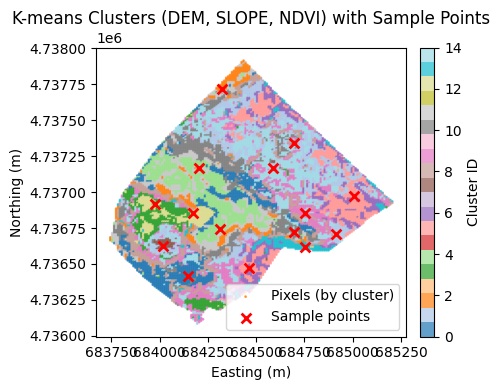

In [29]:
# Visualization of clusters on the AOI area with sample points
plt.figure(figsize=(5, 4))  # Single plot instead of subplot

# Plot all pixels colored by cluster
scatter = plt.scatter(df["x"], df["y"], c=df["cluster"], s=1, cmap="tab20", alpha=0.7, label="Pixels (by cluster)")

# Add sample points on top
plt.scatter(sample_points["x"], sample_points["y"], 
           c="red", marker="x", s=50, linewidth=2, 
           label="Sample points", zorder=5)  # zorder=5 puts them on top

plt.title("K-means Clusters (DEM, SLOPE, NDVI) with Sample Points")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.colorbar(scatter, fraction=0.046, pad=0.04, label="Cluster ID")
plt.legend()
plt.tight_layout()
plt.show()

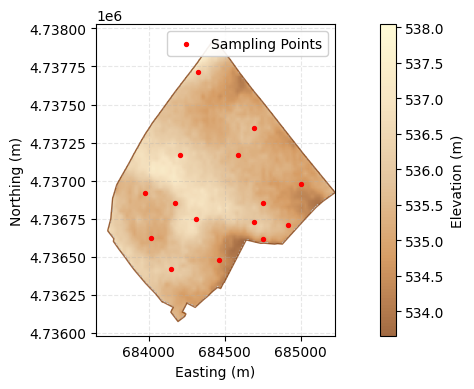

In [30]:
# Just trying to create a pretty visual ;) Needs some more work...

def create_soil_topography_map(ds, sample_points, snap, field_path=None):
    
    # Get DEM data
    dem_data = snap["DEM"].values
    x_coords = snap.x.values
    y_coords = snap.y.values
    
    # Create figure with larger size for better detail
    fig, ax = plt.subplots(figsize=(12, 4))
    
    # Create custom colormap similar to soil maps (browns/tans)
    colors = ['#8B4513', '#CD853F', '#DEB887', '#F5DEB3', '#FFFACD']  # Browns to light tan
    n_bins = 100
    soil_cmap = LinearSegmentedColormap.from_list('soil', colors, N=n_bins)
    
    # Plot DEM as background with soil colors
    extent = [x_coords.min(), x_coords.max(), y_coords.min(), y_coords.max()]
    im = ax.imshow(dem_data, extent=extent, cmap=soil_cmap, alpha=0.8, origin='upper')
    
    # Plot sampling points
    ax.scatter(sample_points["x"], sample_points["y"], 
              c='red', marker='o', s=8, zorder=2, label='Sampling Points')
    
    # Add field boundary if provided
    if field_path:
        try:
            field = gpd.read_file(field_path).to_crs(epsg=32634)
            field.boundary.plot(ax=ax, color='#8B4513', linewidth=1, alpha=0.8)
        except:
            print("Could not load field boundary")
    
    # Styling
    ax.set_xlabel('Easting (m)')
    ax.set_ylabel('Northing (m)')
    
    # Add colorbar for elevation
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Elevation (m)')
    
    # Add legend for sampling points
    ax.legend(framealpha=0.9)
    
    # Add grid
    ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax

# Create the visualization
fig, ax = create_soil_topography_map(
    ds, 
    sample_points, 
    snap,
    field_path="/Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/input/smartsoil_experiment/agrovar_sofia26/field26.shp"
)

In [31]:
# EXPORT TO TIFF FILE (for GIS use or for demo overlay)

# Create output directory
output_dir = Path("/Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/output/demo_layers")
output_dir.mkdir(exist_ok=True)

# Export function
def export_demo_overlay_clean_fixed(df, sample_points, snap, output_path):
    """Export clean overlay with subtle clusters and prominent sample points"""
    
    x_coords = snap.x.values
    y_coords = snap.y.values
    height, width = len(y_coords), len(x_coords)
    
    print(f"Raster dimensions: {height} x {width}")
    print(f"X bounds: {x_coords.min():.1f} to {x_coords.max():.1f}")
    print(f"Y bounds: {y_coords.min():.1f} to {y_coords.max():.1f}")
    
    # Create RGBA bands
    red = np.zeros((height, width), dtype=np.uint8)
    green = np.zeros((height, width), dtype=np.uint8) 
    blue = np.zeros((height, width), dtype=np.uint8)
    alpha = np.zeros((height, width), dtype=np.uint8)  # Transparent background

    # Define earthy colors for 5 clusters (with transparency)
    cluster_colors = {
        0: (120, 150, 100, 200),  # Muted green (R, G, B, Alpha)
        1: (140, 120, 90, 200),   # Brown/tan
        2: (100, 130, 160, 200),  # Muted blue
        3: (160, 140, 100, 200),  # Light brown/beige
        4: (130, 110, 140, 200),  # Muted purple
    }
    
    # Fill cluster pixels with colors
    for _, row in df.iterrows():
        x_idx = np.argmin(np.abs(x_coords - row['x']))
        y_idx = np.argmin(np.abs(y_coords - row['y']))
        
        cluster_id = int(row['cluster'])
        if cluster_id in cluster_colors:
            r, g, b, a = cluster_colors[cluster_id]
            red[y_idx, x_idx] = r
            green[y_idx, x_idx] = g
            blue[y_idx, x_idx] = b
            alpha[y_idx, x_idx] = a  # Semi-transparent clusters
    
    # Mark sample points as red dots 
    for _, point in sample_points.iterrows():
        x_idx = np.argmin(np.abs(x_coords - point['x']))
        y_idx = np.argmin(np.abs(y_coords - point['y']))
        
        # Change the range to adjust size: 
        # range(-1, 2) = 3x3 pixels
        # range(-2, 3) = 5x5 pixels  <-- current
        # range(-3, 4) = 7x7 pixels
        radius = 1  # For circular dots
        for di in range(-radius, radius + 1):
            for dj in range(-radius, radius + 1):
                if di*di + dj*dj <= radius*radius:  # Circle equation
                    if 0 <= y_idx+di < height and 0 <= x_idx+dj < width:
                        red[y_idx+di, x_idx+dj] = 255     # Red
                        green[y_idx+di, x_idx+dj] = 0      # No green
                        blue[y_idx+di, x_idx+dj] = 0       # No blue
                        alpha[y_idx+di, x_idx+dj] = 255    # Fully opaque
    
    # Create proper geotransform
    transform = from_bounds(
        x_coords.min(), y_coords.min(), 
        x_coords.max(), y_coords.max(), 
        width, height
    )
    
    print(f"Transform: {transform}")
    
    # Export with correct CRS (UTM 34N)
    with rasterio.open(
        output_path,
        'w',
        driver='GTiff',
        height=height,
        width=width,
        count=4,  # RGBA
        dtype=np.uint8,
        crs='EPSG:32634',  # UTM Zone 34N (matches data)
        transform=transform,
        compress='lzw'
    ) as dst:
        dst.write(red, 1)     # Red band
        dst.write(green, 2)   # Green band  
        dst.write(blue, 3)    # Blue band
        dst.write(alpha, 4)   # Alpha band
        
        dst.set_band_description(1, 'Red')
        dst.set_band_description(2, 'Green')
        dst.set_band_description(3, 'Blue')
        dst.set_band_description(4, 'Alpha')

# Export with the new color scheme (using buffered data if available, otherwise original)
fixed_path = output_dir / "field26_clusters.tiff"
# Check which variables exist and use the buffered version if available
if 'df_buffered' in dir() and 'sample_points_buffered' in dir():
    export_demo_overlay_clean_fixed(df_buffered, sample_points_buffered, snap, fixed_path)
    print("Exported using buffered sample points")
elif 'df' in dir() and 'sample_points' in dir():
    export_demo_overlay_clean_fixed(df, sample_points, snap, fixed_path)
    print("Exported using original sample points")
else:
    print("Error: No sample points available. Please run the stratification cells first.")

Raster dimensions: 187 x 150
X bounds: 683735.0 to 685225.0
Y bounds: 4736075.0 to 4737935.0
Transform: | 9.93, 0.00, 683735.00|
| 0.00,-9.95, 4737935.00|
| 0.00, 0.00, 1.00|
Exported using buffered sample points


In experiments, for example, there is a possibility of a full factorial design. In a full factorial design, e.g., all combinations of factor levels are observed. If we were to have 2 covariates (lets say application rates for N and P), and 4 levels each. Ideally one would have plots for all 4x4 combinations. With k factors and l levels per factor the total number of observations is l^k. This is referred to as __full factorial design__.

In spatial surveys (like soil sampling) a full factorial design is not feasible. There might be high correlation between some covariates, so specific combitations of factors might not even be observed. Alternative designs have been developed that need less observations but still provide detailed information about how the variable of interest responds to changes in the factor levels. This is where __Latin hypercube sampling__ comes in. Latin hypercube sampling spreads sampling points such that all ranges of covariates are well enough represented, even if not every possible combination exists. 

Source: Brus, 2018

### Latin hypercube sampling (TBD)

Minasny and McBratney (2006) adapted LHS for observational studies, aka conditioned LHS (cLHS). For each covariate a series of intervals (marginal strata) is defined. The breaks are chosen such that the amount of pixels is equal across marginal strata. E.g. for five marginal strata use the qantiles corresponding with the cumulative probabilities 0.2, 0.4, 0.6, and 0.8. 

_**Code TBD ...**_

---

## Validation approaches

We started testing these sampling strategies with real SOC data from BONARES (Brandenburg farms) and pilot fields but it remains in a very early stage. 

**What we tested:**
- Different covariates for stratification (NDVI, EVI, BSI, Elevation, Slope, Aspect)
- Variable importance ranking (composite scores based on variance explained + silhouette)
- Multi-field validation across different farm conditions

**What still needs to be done:**
- Really dig deep into clustering 
- Test if and what kind of stratification helps capture SOC changes over time (temporal validation) and across fields (geographic validation)
- Compare stratified sampling using one vs multiple covariates vs simple random/grid sampling head-to-head
- Figure out what field characteristics determine which strategy works best
- Validate on more pilot sites to get robust recommendations

---

## Sample Size Calculator

#### Sample Size Calculater à la Raosoft

The [Raosoft Sample Size Calculator](http://www.raosoft.com/samplesize.html) is a statistical tool that answers: "How many samples do I actually need to take?"

What it does:
It's based on standard survey sampling theory. You input:

Population size (how many pixels in your field)
Confidence level (95% = you want to be right 19 out of 20 times)
Margin of error (±5% = your estimate can be off by 5%)
Response distribution (50% is most conservative, assumes maximum variability)
And it calculates the minimum number of samples needed to meet those statistical criteria.

The problem for soil sampling:
This calculator assumes you're measuring something simple (like yes/no answers in surveys). But SOC is highly variable and the formula doesn't account for:

How much SOC actually varies within your field
Spatial autocorrelation (nearby points are similar)
Different soil properties have different variability

In [32]:
# Simple Sample Size Calculator (Raosoft-style)

def calculate_sample_size(population_size, confidence_level=95, margin_of_error=5, response_distribution=50):
    """
    Calculate required sample size using Raosoft methodology
    
    Parameters:
    -----------
    population_size : int
        Total number of units in population (e.g., pixels in field)
    confidence_level : float
        Confidence level as percentage (90, 95, or 99)
    margin_of_error : float
        Margin of error as percentage (e.g., 5 for ±5%)
    response_distribution : float
        Expected response distribution as percentage (50 is most conservative)
    
    Returns:
    --------
    dict with sample size and parameters
    """
    from scipy import stats
    
    # Convert percentages to proportions
    E = margin_of_error / 100  # Margin of error
    r = response_distribution  # Keep as percentage for formula
    N = population_size
    
    # Get Z-score for confidence level
    z_scores = {
        90: 1.645,
        95: 1.96,
        99: 2.576
    }
    
    if confidence_level not in z_scores:
        raise ValueError("Confidence level must be 90, 95, or 99")
    
    Z = z_scores[confidence_level]
    
    # Raosoft formulas
    x = (Z**2) * r * (100 - r)
    n = (N * x) / ((N - 1) * (E**2) * 10000 + x)
    
    # Calculate actual margin of error achieved
    E_actual = np.sqrt((N - n) * x / (n * (N - 1))) / 100
    
    results = {
        'recommended_sample_size': int(np.ceil(n)),
        'population_size': N,
        'confidence_level': confidence_level,
        'margin_of_error': margin_of_error,
        'actual_margin_of_error': E_actual * 100,
        'response_distribution': response_distribution,
        'z_score': Z
    }
    
    return results


def print_sample_size_report(results):
    """Print formatted report of sample size calculation"""
    print("-" * 60)
    print("SAMPLE SIZE CALCULATOR RESULTS")
    print("-" * 60)
    print(f"\nPopulation size: {results['population_size']:,} pixels")
    print(f"Confidence level: {results['confidence_level']}%")
    print(f"Margin of error: {results['margin_of_error']}%")
    print(f"Response distribution: {results['response_distribution']}%")
    print(f"\n{'-'*60}")
    print(f"RECOMMENDED SAMPLE SIZE: {results['recommended_sample_size']:,} samples")
    print(f"{'-'*60}")
    print(f"\nThis means: With {results['recommended_sample_size']} samples,")
    print(f"you can be {results['confidence_level']}% confident that your")
    print(f"results are within ±{results['margin_of_error']}% of the true value.")
    print(f"\nPercentage of population sampled: {results['recommended_sample_size']/results['population_size']*100:.2f}%")


def compare_sample_scenarios(population_size):
    """Compare different sampling scenarios"""
    scenarios = [
        {'confidence': 90, 'margin': 10},
        {'confidence': 95, 'margin': 10},
        {'confidence': 95, 'margin': 5},
        {'confidence': 99, 'margin': 5},
        {'confidence': 99, 'margin': 3},
    ]
    
    print("\nCOMPARISON OF DIFFERENT SCENARIOS")
    print("=" * 80)
    print(f"{'Confidence':<12} {'Margin of Error':<18} {'Sample Size':<15} {'% of Population':<15}")
    print("-" * 80)
    
    for scenario in scenarios:
        result = calculate_sample_size(
            population_size, 
            confidence_level=scenario['confidence'],
            margin_of_error=scenario['margin']
        )
        pct = result['recommended_sample_size'] / population_size * 100
        print(f"{scenario['confidence']}%{'':<9} {scenario['margin']}%{'':<15} {result['recommended_sample_size']:<15,} {pct:<.2f}%")


In [33]:
# Apply sample size calculator to Field 26

# Get population size from our field data
population_size = len(df)  # Number of valid pixels in field
print(f"Field 26 population: {population_size:,} pixels\n")

# Calculate recommended sample size with typical parameters
results = calculate_sample_size(
    population_size=population_size,
    confidence_level=95,
    margin_of_error=5,
    response_distribution=50
)

# Print detailed report
print_sample_size_report(results)

# Compare different scenarios
compare_sample_scenarios(population_size)

Field 26 population: 13,821 pixels

------------------------------------------------------------
SAMPLE SIZE CALCULATOR RESULTS
------------------------------------------------------------

Population size: 13,821 pixels
Confidence level: 95%
Margin of error: 5%
Response distribution: 50%

------------------------------------------------------------
RECOMMENDED SAMPLE SIZE: 374 samples
------------------------------------------------------------

This means: With 374 samples,
you can be 95% confident that your
results are within ±5% of the true value.

Percentage of population sampled: 2.71%

COMPARISON OF DIFFERENT SCENARIOS
Confidence   Margin of Error    Sample Size     % of Population
--------------------------------------------------------------------------------
90%          10%                68              0.49%
95%          10%                96              0.69%
95%          5%                374             2.71%
99%          5%                634             4.59%
99%    

---

### Limitation of Raosoft for Soil Sampling

**The Raosoft calculator above is designed for categorical survey data (yes/no questions), not continuous measurements like SOC.**

The "response distribution" parameter doesn't apply to soil carbon. Instead, we need:
- **Coefficient of Variation (CV)** - measures field heterogeneity
- **Minimum Detectable Difference (MDD)** - SOC change we want to detect over time

**Better approach for soil sampling:** Use field heterogeneity (e.g., NDVI variability) to estimate required sample size.

### Soil-Specific Sample Size Calculator

This calculator uses **field heterogeneity** (measured via NDVI) and **desired precision** for SOC measurements.

Scenario 1: Gives you minimum sample size (if SOC behaves like NDVI)
Scenario 2: Gives you safe sample size (if SOC is more variable)

In [34]:
# Sample Size Calculator for Soil Carbon Monitoring

def calculate_soil_sample_size(
    field_cv,
    confidence_level=95,
    desired_precision=10,
    population_size=None
):
    """
    Calculate sample size for continuous soil measurements based on field heterogeneity
    
    Parameters:
    -----------
    field_cv : float
        Coefficient of Variation (CV) of the field as percentage
        Higher CV = more heterogeneous field = need more samples
    confidence_level : float
        Confidence level (90, 95, or 99)
    desired_precision : float
        Desired precision as percentage of the mean (e.g., 10 = ±10% of mean)
        For SOC: if mean is 2.5%, precision of 10% means ±0.25% absolute
    population_size : int, optional
        Total number of pixels in field (for finite population correction)
    
    Returns:
    --------
    dict with sample size and parameters
    """
    from scipy import stats
    
    # Z-scores for confidence levels
    z_scores = {90: 1.645, 95: 1.96, 99: 2.576}
    
    if confidence_level not in z_scores:
        raise ValueError("Confidence level must be 90, 95, or 99")
    
    Z = z_scores[confidence_level]
    CV = field_cv  # Coefficient of variation as percentage
    E = desired_precision  # Desired precision as percentage
    
    # Sample size for infinite population
    # n = (Z * CV / E)^2
    n_infinite = (Z * CV / E) ** 2
    
    # Apply finite population correction if population size known
    if population_size is not None and population_size > 0:
        # Finite population correction: n_adj = n / (1 + (n-1)/N)
        n_adjusted = n_infinite / (1 + (n_infinite - 1) / population_size)
    else:
        n_adjusted = n_infinite
    
    # Calculate actual precision achieved
    if population_size is not None:
        actual_precision = Z * CV / np.sqrt(n_adjusted) * np.sqrt((population_size - n_adjusted) / population_size)
    else:
        actual_precision = Z * CV / np.sqrt(n_adjusted)
    
    results = {
        'recommended_sample_size': int(np.ceil(n_adjusted)),
        'field_cv': field_cv,
        'confidence_level': confidence_level,
        'desired_precision': desired_precision,
        'actual_precision': actual_precision,
        'population_size': population_size,
        'infinite_pop_size': int(np.ceil(n_infinite)),
        'z_score': Z
    }
    
    return results


def estimate_cv_from_ndvi(ndvi_values):
    """
    Estimate field heterogeneity using NDVI as proxy
    
    Returns CV (coefficient of variation) as percentage
    """
    # Remove NaN values
    ndvi_clean = ndvi_values[~np.isnan(ndvi_values)]
    
    mean_ndvi = np.mean(ndvi_clean)
    std_ndvi = np.std(ndvi_clean)
    cv_ndvi = (std_ndvi / mean_ndvi) * 100
    
    return {
        'cv_percent': cv_ndvi,
        'mean': mean_ndvi,
        'std': std_ndvi,
        'min': np.min(ndvi_clean),
        'max': np.max(ndvi_clean),
        'n_pixels': len(ndvi_clean)
    }


def print_soil_sample_report(results, ndvi_stats=None):
    """Print formatted report for soil sampling"""
    
    if ndvi_stats:
        print(f"Field CV (from NDVI): {ndvi_stats['cv_percent']:.1f}% → {'Low' if ndvi_stats['cv_percent'] < 15 else 'Moderate' if ndvi_stats['cv_percent'] < 30 else 'High'} heterogeneity")
    
    print(f"\n{'='*60}")
    print(f"RECOMMENDED SAMPLE SIZE: {results['recommended_sample_size']} samples")
    print(f"{'='*60}")
    
    print(f"\nParameters: {results['confidence_level']}% confidence, ±{results['desired_precision']}% precision, CV={results['field_cv']:.1f}%")
    
    if results['population_size']:
        pct_sampled = results['recommended_sample_size'] / results['population_size'] * 100
        print(f"Sampling {pct_sampled:.2f}% of {results['population_size']:,} pixels")
    
    print(f"\nExample: If true mean SOC = 2.5%, your estimate will be between " 
          f"{2.5 * (1 - results['desired_precision']/100):.2f}%-{2.5 * (1 + results['desired_precision']/100):.2f}%")


def compare_cv_scenarios(population_size, cv_values=[10, 20, 30, 40]):
    """Compare sample sizes for different field heterogeneity levels"""
    print("\nField heterogeneity vs sample size (95% confidence, ±10% precision):")
    print(f"{'CV':<8} {'Heterogeneity':<15} {'Samples needed':<15}")
    print("-" * 40)
    
    labels = {10: "Low", 20: "Moderate", 30: "High", 40: "Very High"}
    
    for cv in cv_values:
        result = calculate_soil_sample_size(cv, 95, 10, population_size)
        print(f"{cv}%{'':<5} {labels.get(cv, 'Variable'):<15} {result['recommended_sample_size']:<15}")

In [35]:
# Apply soil-specific calculator to Field 26

# Step 1: Estimate field heterogeneity from NDVI
ndvi_data = snap["NDVI"].values.flatten()
ndvi_stats = estimate_cv_from_ndvi(ndvi_data)

print("FIELD 26 HETEROGENEITY ANALYSIS")
print("-" * 70)
print(f"Using NDVI from growing season (April-September 2018)")
print(f"Pixels analyzed: {ndvi_stats['n_pixels']:,}")
print(f"\nNDVI Statistics:")
print(f"  Mean: {ndvi_stats['mean']:.3f}")
print(f"  Std Dev: {ndvi_stats['std']:.3f}")
print(f"  Range: {ndvi_stats['min']:.3f} to {ndvi_stats['max']:.3f}")
print(f"  Coefficient of Variation: {ndvi_stats['cv_percent']:.1f}%")
print(f"\n→ Field 26 shows {'LOW' if ndvi_stats['cv_percent'] < 15 else 'MODERATE' if ndvi_stats['cv_percent'] < 25 else 'HIGH'} heterogeneity")

# Step 2: Calculate required sample size using NDVI CV as proxy for SOC variability
# Assuming SOC has similar or higher variability than NDVI
# Conservative approach: use NDVI CV or assume slightly higher

# Use NDVI CV as lower bound (optimistic)
cv_optimistic = ndvi_stats['cv_percent']
# Use 1.5x NDVI CV as upper bound (conservative, SOC often more variable)
cv_conservative = ndvi_stats['cv_percent'] * 1.5

print("\n" + "-" * 70)
print("SAMPLE SIZE CALCULATION")
print("-" * 70)

print(f"\nScenario 1: SOC variability similar to NDVI (CV = {cv_optimistic:.1f}%)")
results_opt = calculate_soil_sample_size(
    field_cv=cv_optimistic,
    confidence_level=95,
    desired_precision=10,
    population_size=ndvi_stats['n_pixels']
)
print_soil_sample_report(results_opt)

print("\n\n" + "-" * 70)
print(f"Scenario 2: SOC more variable than NDVI (CV = {cv_conservative:.1f}%)")
results_cons = calculate_soil_sample_size(
    field_cv=cv_conservative,
    confidence_level=95,
    desired_precision=10,
    population_size=ndvi_stats['n_pixels']
)
print_soil_sample_report(results_cons)

# Step 3: Show impact of different heterogeneity levels
compare_cv_scenarios(ndvi_stats['n_pixels'])

print("\n" + "-" * 70)
print("RECOMMENDATION FOR FIELD 26")
print("-" * 70)
print(f"Sample size range: {results_opt['recommended_sample_size']} - {results_cons['recommended_sample_size']} samples")
print(f"\nIf you have actual SOC data from pilot sampling, calculate its CV")
print(f"to refine this estimate. Otherwise, use {results_cons['recommended_sample_size']} (conservative).")

FIELD 26 HETEROGENEITY ANALYSIS
----------------------------------------------------------------------
Using NDVI from growing season (April-September 2018)
Pixels analyzed: 13,951

NDVI Statistics:
  Mean: 0.546
  Std Dev: 0.032
  Range: 0.333 to 0.736
  Coefficient of Variation: 5.9%

→ Field 26 shows LOW heterogeneity

----------------------------------------------------------------------
SAMPLE SIZE CALCULATION
----------------------------------------------------------------------

Scenario 1: SOC variability similar to NDVI (CV = 5.9%)

RECOMMENDED SAMPLE SIZE: 2 samples

Parameters: 95% confidence, ±10% precision, CV=5.9%
Sampling 0.01% of 13,951 pixels

Example: If true mean SOC = 2.5%, your estimate will be between 2.25%-2.75%


----------------------------------------------------------------------
Scenario 2: SOC more variable than NDVI (CV = 8.9%)

RECOMMENDED SAMPLE SIZE: 4 samples

Parameters: 95% confidence, ±10% precision, CV=8.9%
Sampling 0.03% of 13,951 pixels

Example:

#### Key Insights

**Response Distribution in Soil Context:**

The Raosoft "response distribution" doesn't apply to continuous soil measurements. Instead:

1. **Field Heterogeneity = Coefficient of Variation (CV)**
   - CV = (standard deviation / mean) × 100
   - Low CV (10-15%): Uniform field → fewer samples needed
   - High CV (30-40%): Heterogeneous field → more samples needed

2. **NDVI as Proxy for SOC Heterogeneity**
   - NDVI variability indicates vegetation/soil differences
   - More heterogeneous NDVI → likely more heterogeneous SOC
   - Conservative: assume SOC CV is 1.5× NDVI CV

3. **Desired Precision (not Margin of Error)**
   - ±10% precision: if mean SOC = 2.5%, your estimate will be 2.25-2.75%
   - ±5% precision: requires ~4× more samples than ±10%

4. **Detecting SOC Changes Over Time**
   - For monitoring, you need: current sample size + follow-up sample size
   - The Minimum Detectable Difference (MDD) depends on both sample size AND field CV
   - See Power Analysis section below for temporal change detection

**Bottom line:** More heterogeneous fields need more samples to achieve the same precision OR to detect the same magnitude of change over time.

## Power Analysis

We want a suitable __power analysis__ method for determining the “optimal” sampling size ex-ante. Ideally, the power analysis could then be integrated into the stratification workflow such that the outcomes were both where to collect samples and how many samples to collect.

Traditional power analysis approach: determines the necessary number of samples to detect a specific magnitude of change in a sample population given its background variability.

__Statistical significance__: is a term used to indicate whether an observed difference could have occurred by chance or reflects a genuine change. In the context of soil carbon removals, statistical significance is used to determine whether sequestration really has taken place, or whether the data just reflects the natural variability of the soil. This is relevant for the sampling strategy, because we need a sampling strategy that is sensitive enough to detect an expected magnitude of change in the future. The smaller the change you expect to see, the more sensitive the sampling needs to be.  

Which brings us the the __Minimum Detectable Difference (MDD)__. The MDD is the smallest difference between two datasets, that you can confidently say is a real change. The anticipated change in measurement must be larger than the MDD of our sampling strategy. The MDD is calculated using Power analysis and is influence by the variability of the data and the sample size.

Typically, carbon farming projects hope to achieve an average increase in SOC stock of around 1 t/ha/year, so 5 t/ha/5 years. In this case we need to design a sampling strategy around a MDD of 5 t/ha. 

Source: Agricarbon

To Do:
- Link it to the BONARES Data on SOC
- Get an estimate on the variability of SOC over time for different sampling locations


In the meantime, just assume something ...

__Power analysis framework__

Effect size: Minimum detectable difference in SOC content
Type I error (α): Probability of false positive (typically 0.05)
Type II error (β): Probability of false negative
Power (1-β): Probability of detecting true effect

In [36]:
# Power Analysis for Soil Carbon Studies - Python version

def soil_carbon_power_analysis(
    effect_size_range=np.arange(0.1, 1.1, 0.1),
    alpha=0.05,
    power=0.80,
    cv_range=[0.15, 0.25, 0.35],  # Coefficient of variation
    baseline_soc=2.5,  # Baseline SOC %
    study_design="two_sample"
):
    """
    Calculate sample size requirements for soil carbon studies
    """
    results = []
    
    for cv in cv_range:
        for es in effect_size_range:
            # Convert effect size to Cohen's d
            mean_diff = baseline_soc * es
            pooled_sd = baseline_soc * cv
            cohens_d = mean_diff / pooled_sd
            
            # Calculate required sample size using power analysis
            if study_design == "two_sample":
                # Two-sample t-test
                delta = cohens_d
                t_alpha = stats.t.ppf(1 - alpha/2, df=1000)  # approximate
                t_beta = stats.t.ppf(power, df=1000)
                n = 2 * ((t_alpha + t_beta) / delta) ** 2
            elif study_design == "paired":
                # Paired t-test
                delta = cohens_d
                t_alpha = stats.t.ppf(1 - alpha/2, df=1000)
                t_beta = stats.t.ppf(power, df=1000)
                n = ((t_alpha + t_beta) / delta) ** 2
            
            results.append({
                'effect_size': es,
                'sample_size': int(np.ceil(n)),
                'cv': cv,
                'cohens_d': cohens_d
            })
    
    return pd.DataFrame(results)

def spatial_power_analysis(
    grid_spacing=[10, 20, 50, 100],  # meters
    plot_size=10000,  # m²
    soc_variance=0.5,
    spatial_range=50,  # meters
    nugget_effect=0.3
):
    """
    Analyze power considering spatial autocorrelation
    """
    results = []
    
    for spacing in grid_spacing:
        # Calculate number of samples
        samples_per_side = np.sqrt(plot_size) / spacing
        total_samples = samples_per_side ** 2
        
        # Estimate effective sample size considering spatial correlation
        # Using exponential decay model
        max_distance = spacing * np.sqrt(2)
        correlation = np.exp(-max_distance / spatial_range)
        
        # Effective sample size (Dutilleul's method)
        effective_n = total_samples / (1 + (total_samples - 1) * correlation)
        
        # Minimum detectable difference
        se = np.sqrt(soc_variance / effective_n)
        # Two-sided t-test at 95% confidence
        t_critical = stats.t.ppf(0.975, df=max(1, effective_n - 1))
        mdd = t_critical * se * np.sqrt(2)
        
        results.append({
            'grid_spacing': spacing,
            'total_samples': int(total_samples),
            'effective_samples': int(np.round(effective_n)),
            'min_detectable_diff': mdd,
            'relative_mdd': mdd / 2.5 * 100  # as percentage of baseline SOC
        })
    
    return pd.DataFrame(results)

def stratified_power_analysis(
    strata_props=[0.4, 0.3, 0.2, 0.1],  # Proportion of each stratum
    strata_vars=[0.2, 0.4, 0.6, 0.8],   # Variance in each stratum
    total_budget=1000,  # Total sampling budget
    cost_per_sample=50
):
    """
    Optimize sample allocation across strata
    """
    max_samples = total_budget // cost_per_sample
    
    # Optimal allocation using Neyman allocation
    strata_props = np.array(strata_props)
    strata_vars = np.array(strata_vars)
    
    numerator = strata_props * np.sqrt(strata_vars)
    allocation_factors = numerator / np.sum(numerator)
    
    optimal_allocation = np.round(max_samples * allocation_factors).astype(int)
    
    # Calculate variance of stratified mean
    stratified_variance = np.sum((strata_props**2 * strata_vars) / optimal_allocation)
    se_stratified = np.sqrt(stratified_variance)
    
    # Compare with simple random sampling
    overall_variance = np.sum(strata_props * strata_vars)
    se_srs = np.sqrt(overall_variance / max_samples)
    
    efficiency_gain = se_srs / se_stratified
    
    strata_summary = pd.DataFrame({
        'stratum': range(1, len(strata_props) + 1),
        'proportion': strata_props,
        'variance': strata_vars,
        'sample_size': optimal_allocation
    })
    
    return {
        'optimal_allocation': optimal_allocation,
        'stratified_se': se_stratified,
        'srs_se': se_srs,
        'efficiency_gain': efficiency_gain,
        'strata_summary': strata_summary
    }

# Run the analyses
print("Running power analyses...")

# 1. Basic power analysis
power_results = soil_carbon_power_analysis()
print(f"Basic power analysis complete: {len(power_results)} scenarios")

# 2. Spatial power analysis
spatial_results = spatial_power_analysis()
print(f"Spatial power analysis complete: {len(spatial_results)} scenarios")

# 3. Stratified sampling analysis
stratified_results = stratified_power_analysis()
print("Stratified sampling analysis complete")

# Display results
print("\n" + "="*50)
print("POWER ANALYSIS RESULTS")
print("="*50)

print("\n1. Sample Size Requirements (Basic Power Analysis)")
print("Effect Size = 20% of baseline (typical for 5-year SOC change)")
subset = power_results[power_results['effect_size'] == 0.2]
print(subset[['cv', 'sample_size', 'cohens_d']].to_string(index=False))

print("\n2. Spatial Sampling Efficiency")
print(spatial_results.to_string(index=False))

print(f"\n3. Stratified vs Simple Random Sampling")
print(f"Efficiency gain: {stratified_results['efficiency_gain']:.2f}x")
print(f"Stratified SE: {stratified_results['stratified_se']:.4f}")
print(f"Simple Random SE: {stratified_results['srs_se']:.4f}")
print("\nOptimal allocation across strata:")
print(stratified_results['strata_summary'].to_string(index=False))

Running power analyses...
Basic power analysis complete: 30 scenarios
Spatial power analysis complete: 4 scenarios
Stratified sampling analysis complete

POWER ANALYSIS RESULTS

1. Sample Size Requirements (Basic Power Analysis)
Effect Size = 20% of baseline (typical for 5-year SOC change)
  cv  sample_size  cohens_d
0.15            9  1.333333
0.25           25  0.800000
0.35           49  0.571429

2. Spatial Sampling Efficiency
 grid_spacing  total_samples  effective_samples  min_detectable_diff  relative_mdd
           10            100                  1            11.048569    441.942751
           20             25                  2             9.720470    388.818795
           50              4                  2             4.850070    194.002788
          100              1                  1            12.706205    508.248189

3. Stratified vs Simple Random Sampling
Efficiency gain: 1.03x
Stratified SE: 0.1371
Simple Random SE: 0.1414

Optimal allocation across strata:
 str

**Bottom Line:**

This analysis is educational but not actionable because:
- Shows the concepts only
- Uses placeholder assumptions for variance, spatial correlation, stratum properties
- Spatial analysis suggests you need 100m+ spacing (probably too conservative with dummy data)

---